<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day09_practice2_mAP_%EC%9D%B4%ED%95%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# mAP 해부 - YOLO 학습 결과를 읽기 위한 법

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 셀 1. 상황 설정 - 포트홀 4개가 있는 사진들, 예측 6개

preds = [ # (신뢰도, 맞았나)
    (0.95, True),
    (0.88, True),
    (0.80, False),
    (0.70, True),
    (0.55, False),
    (0.40, True),
]
N_GT = 4 # 실제 포트홀 개수 (GT = Ground Truth, 정답)

In [6]:
# 셀 2. precision / recall - threshold(문턱)을 정해야 계산된다
# confidence ≥ threshold(문턱)인 예측만 "채택"한다고 하면:
#   precision(정밀도) = 채택 중 정답 비율
#   recall(재현율) = 전체 정답 중 찾은 비율
def pr_at(threshold):
  taken = [ok for c, ok in preds if c >= threshold] # True는 1, False는 0
  tp = sum(taken) # TP = True Positive(맞게 채택한 수)
  precision = tp / len(taken) if taken else 1.0
  recall = tp / N_GT
  return precision, recall

print("threshold(문턱)에 따른 변화:")
for thr in [0.90, 0.75, 0.50, 0.30]:
  p, r = pr_at(thr)
  print(f"  threshold(문턱) {thr:.2f} → precision {p:.2f} | recall {r:.2f}")
# 트레이드 오프
# threshold(문턱)↑ → 확실한 것만 말함 → precision↑, recall↓ (놓치는게 많다) : 자동 차단기 '오작동의 위험'
# threshold(문턱)↑ → 다 말해버림 → recall↑, precision↓ (헛소리가 많다) : 신고 앱 '놓치면 위험'

threshold(문턱)에 따른 변화:
  threshold(문턱) 0.90 → precision 1.00 | recall 0.25
  threshold(문턱) 0.75 → precision 0.67 | recall 0.50
  threshold(문턱) 0.50 → precision 0.60 | recall 0.75
  threshold(문턱) 0.30 → precision 0.67 | recall 1.00


In [7]:
# 셀 3. PR(precision, recall) 곡선과 AP(곡선 이래 넓이) - threshold '전체'를 한 번에 평가
# 예측을 신뢰도 순으로 하나씩 채택해가며 (precision, recall) 점을 찍는다

precisions, recalls = [], []
tp = 0

for i, (c, ok) in enumerate(preds, start=1):
  tp += ok
  precisions.append(tp / i)
  recalls.append(tp / N_GT)
  print(f"{i}개 채택: precision {tp}/{i} = {tp/i:.2f} | recall {tp}/{N_GT} = {tp/N_GT:.2f}")

1개 채택: precision 1/1 = 1.00 | recall 1/4 = 0.25
2개 채택: precision 2/2 = 1.00 | recall 2/4 = 0.50
3개 채택: precision 2/3 = 0.67 | recall 2/4 = 0.50
4개 채택: precision 3/4 = 0.75 | recall 3/4 = 0.75
5개 채택: precision 3/5 = 0.60 | recall 3/4 = 0.75
6개 채택: precision 4/6 = 0.67 | recall 4/4 = 1.00


AP(곡선 아래 넓이) - 0.864


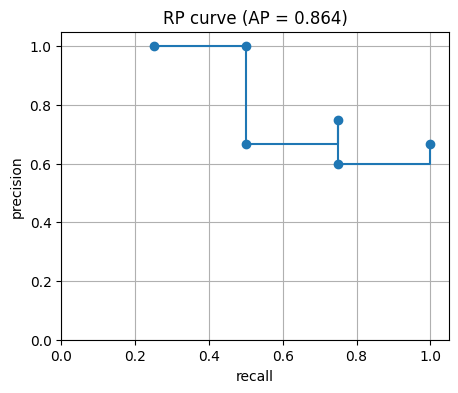

In [9]:
# AP = PR 곡선 아래 넓이
# 11점 보간(11-point interpolation): 넓이를 재는 방식
# recall 기준선 11개(0, 0.1, ..., 1.0)마다 "그 recall 이상에서 낼 수 있는 최고 precision"을 구해 11로 나눠 더함 → 그 합이 AP
recall_levels = np.linspace(0,1,11)
ap = 0.0
for r_level in recall_levels:
  ps = [p for p, r in zip(precisions, recalls) if r >= r_level] # recall이 기준선 r_level 이상인 쌍만 통과, 통과한 쌍에서 precisions만 뽑아 새 리스트
  ap += (max(ps) if ps else 0.0) / 11
print(f"AP(곡선 아래 넓이) - {ap:.3f}")
plt.figure(figsize=(5,4))
plt.step(recalls, precisions, where="post", marker="o")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title(f"RP curve (AP = {ap:.3f})")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True)
plt.savefig("plot1_pr_curve.png")
plt.show()
# 좋은 모델은 오른쪽 벽에 다다를 때까지 가로로 높게 버티다 늦게 떨어짐. 나쁜 모델은 일찍 많이 떨어짐

In [11]:
# 셀 4. mAP50과 mAP50-95 - YOLO 성적표의 두 숫자
# IoU ≥ 0.5면 정답 → AP50
# mAP50 = 클래스별 AP50의 평균, (포트홀 AP + 균열 AP + 맨홀 AP ...의 평균)
# mAP50-95 = IoU 기준을 0.5, 0.55, ..., 0.95로 바꿔가며 채점한 AP들의 평균
# mAP50-95는 항상 mAP50보다 낮다

print("""
              precision  recall  mAP50   mAP50-95
  all           0.85     0.78    0.82    0.55
  pothole       0.90     0.85    0.89    0.62
  crack         0.75     0.65    0.70    0.43   ← all 보다 crack이 결과가 약하다! ← 데이터 보강
  """)


              precision  recall  mAP50   mAP50-95
  all           0.85     0.78    0.82    0.55
  pothole       0.90     0.85    0.89    0.62
  crack         0.75     0.65    0.70    0.43   ← all 보다 crack(균열)이 결과가 약하다! ← 데이터 보강
  
